# EDA for house prices

In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
# Ignoring all future warnings
warnings.filterwarnings('ignore', category = FutureWarning)

In [236]:
data = pd.read_csv("train.csv")
data.drop(columns = "Id", inplace = True)
data.sample(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1041,60,RL,NaN,9130,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,173000
1357,20,RL,NaN,12537,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,149900
1373,20,RL,NaN,11400,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,466500
1391,90,RL,65.0,8944,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,124000
856,80,RL,NaN,10970,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,10,2008,WD,Normal,147000


In [237]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [238]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

## Checking the distribution of the target

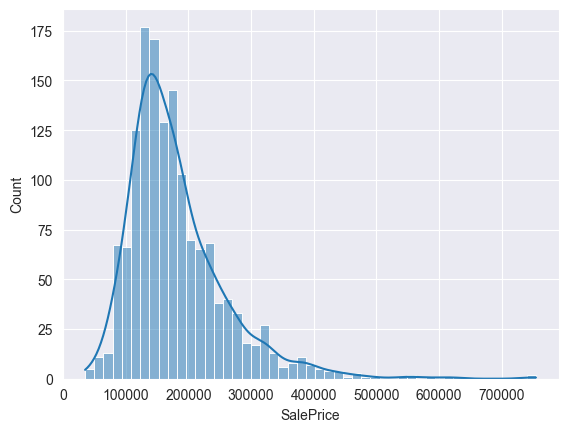

In [239]:
sns.histplot(x = "SalePrice", data = data, kde = True)
plt.show()

Seems like the feature is right skewed, suggesting expensive houses are less in number.

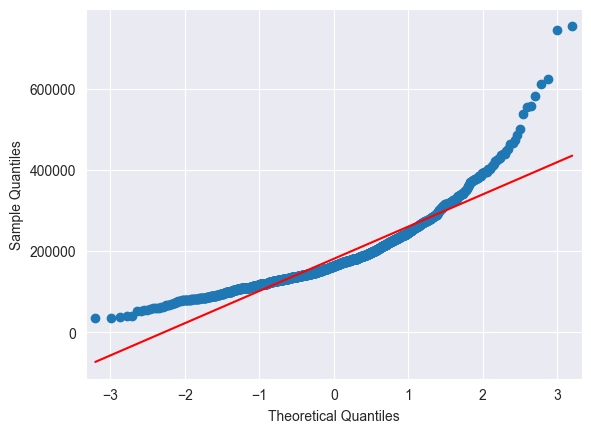

In [240]:
sm.qqplot(data["SalePrice"], line = "s", linewidth = 2)
plt.show()

Maybe log transform will help us. will do it later. So we have to **Log Transform the target** Later

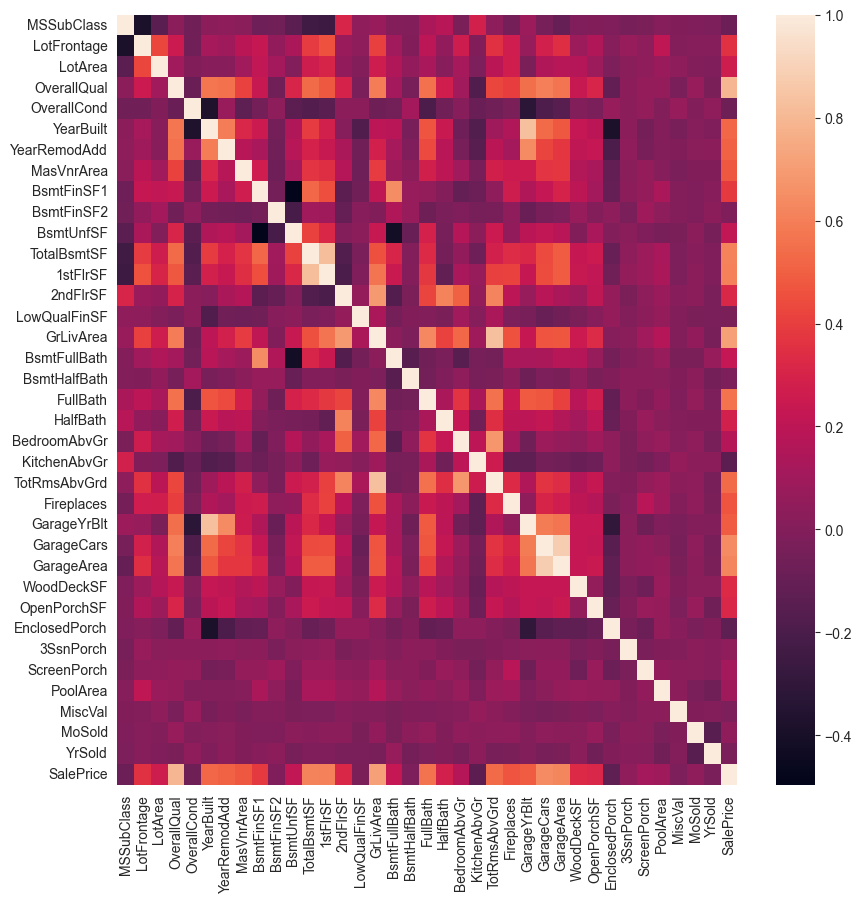

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [241]:
plt.figure(figsize=(10,10))
sns.heatmap(data.select_dtypes(exclude = "object").corr())
plt.show()
data.select_dtypes(exclude = "object").corr()["SalePrice"].sort_values(ascending = False)[:10]

seems like features like GrLivArea, OverallQual, GarageCars, GarageArea, FullBath, etc are the features that affect it a lot.
Lets make a hypothesis.

**GrLiveArea affects the SalePrice and is predictive in predicting SalePrice.**

Now Lets test it!

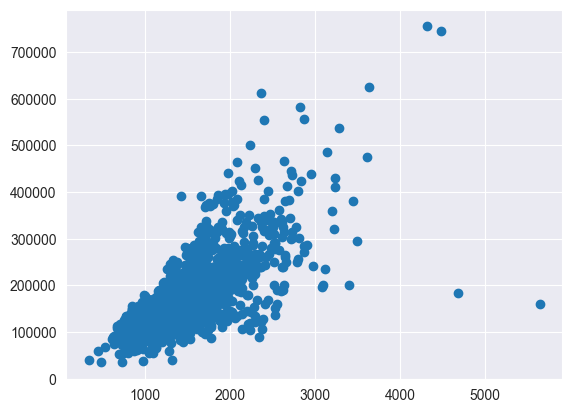

In [242]:
plt.scatter(data["GrLivArea"], data["SalePrice"])
plt.show()

uhmm.... lets look at the distribution a bit

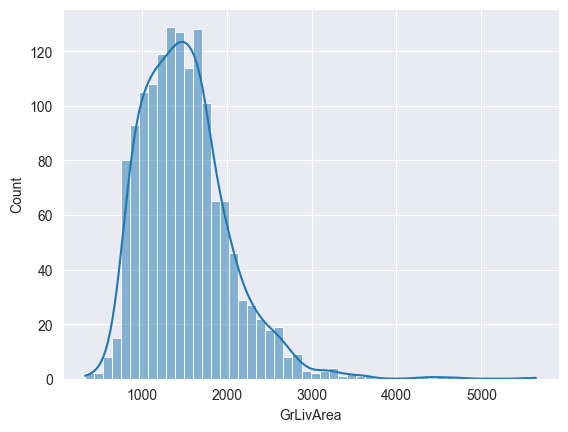

np.float64(1.3665603560164552)

In [243]:
sns.histplot(data["GrLivArea"], bins = 50, kde = True)
plt.show()
data["GrLivArea"].skew()

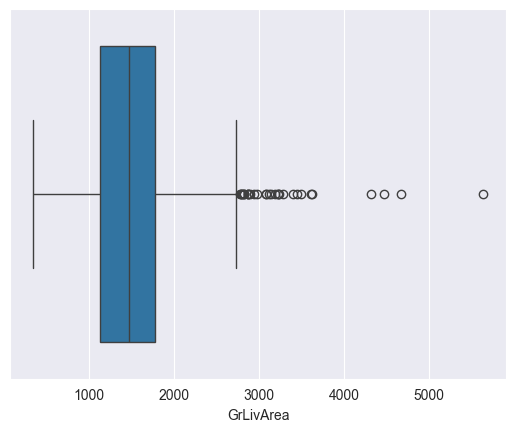

In [244]:
sns.boxplot(x = "GrLivArea", data = data)
plt.show()

seems like there is a skew and a bit of outliers. lets reduce it with a log transform magic. there are even huge houses with area around 3500-5700. these pretty much seem like huge houses the errors. also the data is concentrated in the middle.

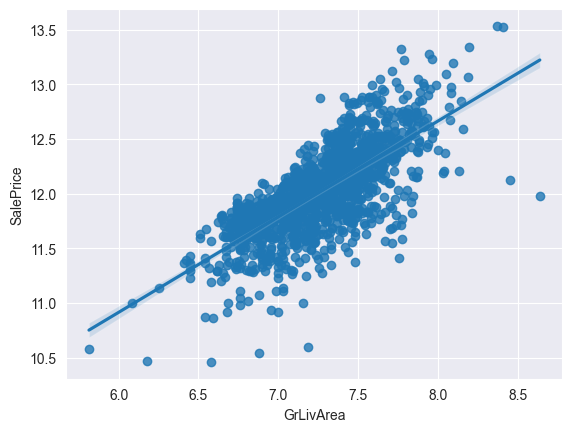

In [245]:
data[["GrLivArea","SalePrice"]] = np.log1p(data[["GrLivArea","SalePrice"]])
sns.regplot(x = "GrLivArea", y = "SalePrice", data = data)
plt.show()


Seems like it is indeed predective! just needed to use those log transforms. lets see its correlation with other features

In [246]:
data.select_dtypes(exclude = "object").corr()["GrLivArea"].drop(index = "GrLivArea").sort_values(ascending = False)

TotRmsAbvGrd     0.825521
SalePrice        0.730254
2ndFlrSF         0.662944
FullBath         0.653167
OverallQual      0.614207
1stFlrSF         0.551440
BedroomAbvGr     0.538848
GarageCars       0.496126
GarageArea       0.476164
Fireplaces       0.468924
TotalBsmtSF      0.435860
HalfBath         0.430454
LotFrontage      0.366469
MasVnrArea       0.363743
OpenPorchSF      0.320793
YearRemodAdd     0.311456
BsmtUnfSF        0.268192
GarageYrBlt      0.254821
LotArea          0.245373
WoodDeckSF       0.240979
YearBuilt        0.235500
BsmtFinSF1       0.163931
KitchenAbvGr     0.111909
PoolArea         0.109771
LowQualFinSF     0.108151
ScreenPorch      0.105955
MSSubClass       0.081715
MoSold           0.066083
3SsnPorch        0.033086
BsmtFullBath     0.020664
EnclosedPorch    0.003328
MiscVal         -0.010049
BsmtFinSF2      -0.012766
BsmtHalfBath    -0.017873
YrSold          -0.030975
OverallCond     -0.101960
Name: GrLivArea, dtype: float64

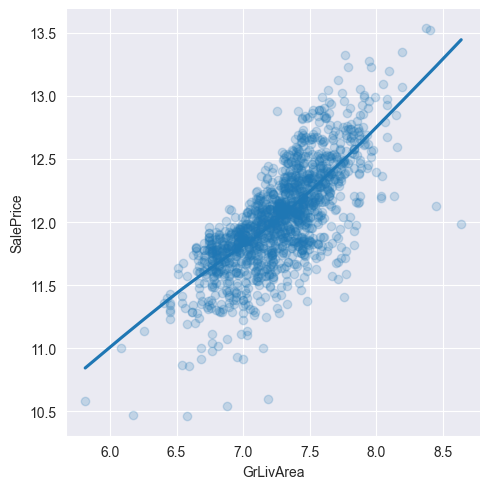

In [247]:
sns.lmplot(x="GrLivArea", y="SalePrice", data=data, lowess=True, scatter_kws={'alpha':0.2})

so this is feature is indeed correlated. Next lets see overall qual.

In [248]:
data["OverallQual"].value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

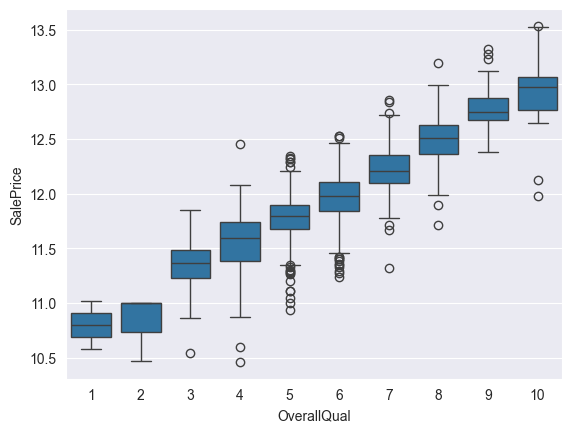

In [249]:
sns.boxplot(x = "OverallQual", y = "SalePrice", data = data)
plt.show()

seems the data is predictive but imbalnced. lets do target mean encoding.

great! now lets see who is next on the list to be tested.


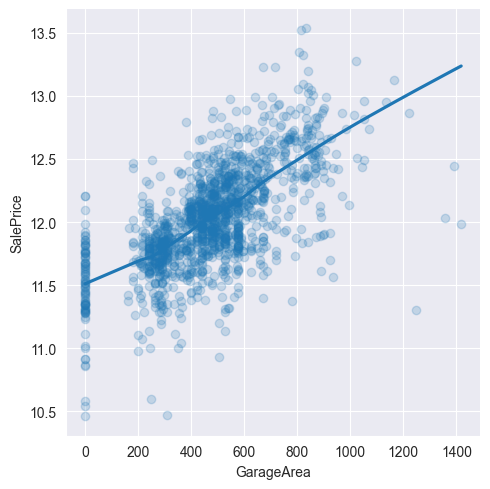

In [250]:
sns.lmplot(x = "GarageArea", y = "SalePrice", data = data, lowess=True, scatter_kws={'alpha':0.2})
plt.show()

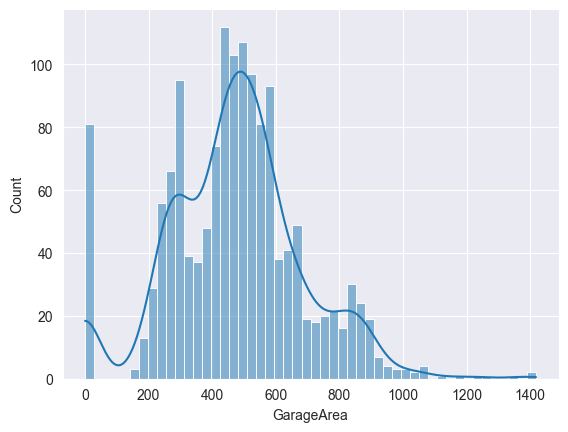

In [251]:
sns.histplot(x = "GarageArea", data = data, bins = 50, kde = True)
plt.show()

C:\Users\rohit\AppData\Local\Temp\ipykernel_27076\95102714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["GarageArea"][data["GarageArea"] != 0] = np.log(data["GarageArea"][data["GarageArea"] != 0])


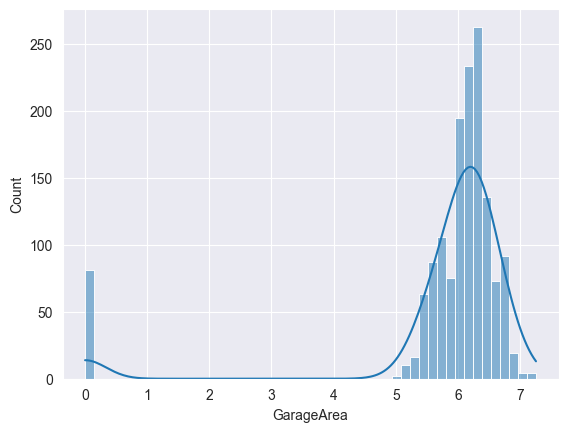

In [252]:
data["GarageArea"][data["GarageArea"] != 0] = np.log(data["GarageArea"][data["GarageArea"] != 0])
sns.histplot(x = "GarageArea", data = data, bins = 50, kde = True)
plt.show()

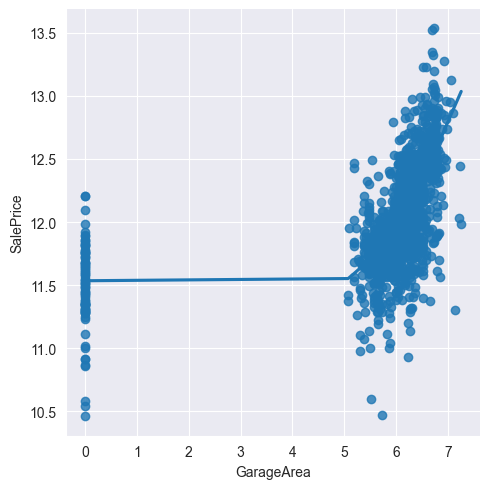

In [253]:
sns.lmplot(x = "GarageArea", y = "SalePrice", data = data, lowess = True)
plt.show()

now lets see garage cars

In [254]:
data["GarageCars"].value_counts()

GarageCars
2    824
1    369
3    181
0     81
4      5
Name: count, dtype: int64

looks imbalanced. lets try mean value imputation

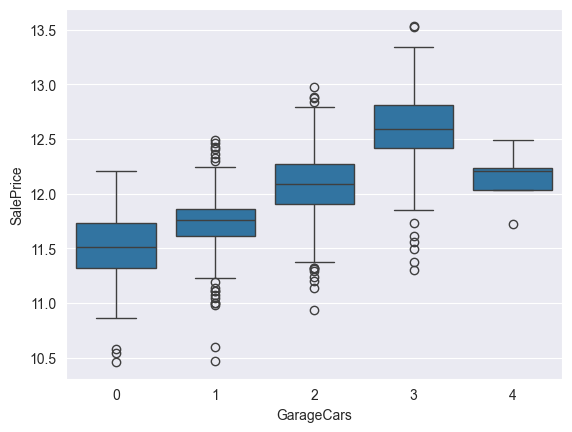

np.float64(0.6806248726581904)

In [255]:
sns.boxplot(x = "GarageCars", y = "SalePrice", data = data)
plt.show()
data["SalePrice"].corr(data["GarageCars"])

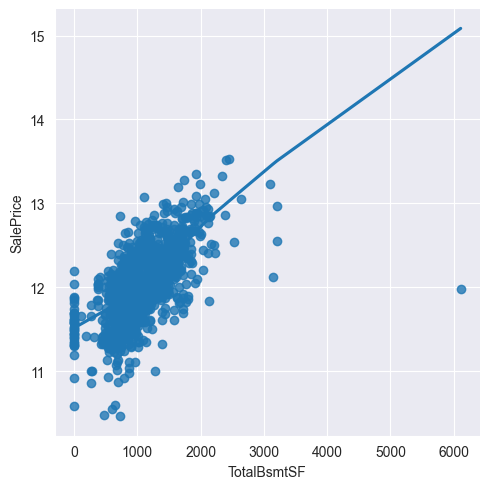

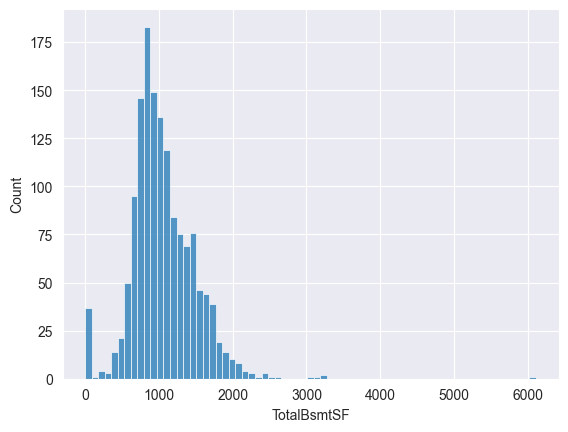

In [256]:
sns.lmplot(x ="TotalBsmtSF", y = "SalePrice", data = data,lowess=True)
plt.show()
sns.histplot(x = "TotalBsmtSF", data = data)
plt.show()

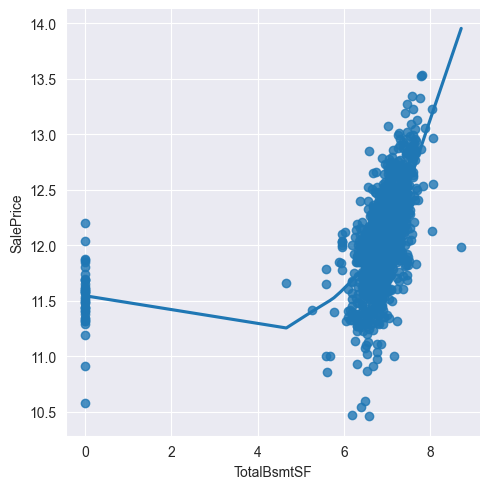

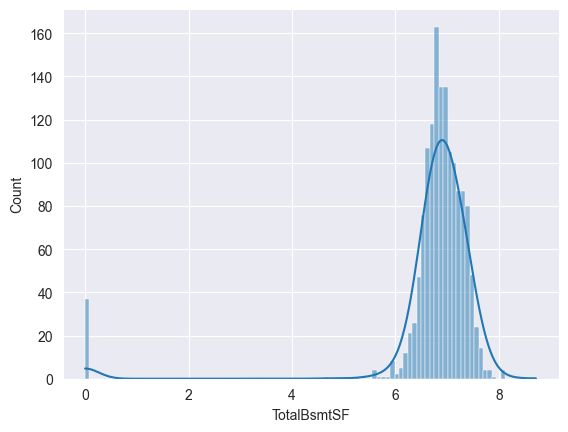

In [257]:
data["TotalBsmtSF"] = np.log1p(data["TotalBsmtSF"])
sns.lmplot(x ="TotalBsmtSF", y = "SalePrice", data = data,lowess=True)
plt.show()
sns.histplot(x = "TotalBsmtSF", data = data, kde = True)
plt.show()

now lets see the missing values

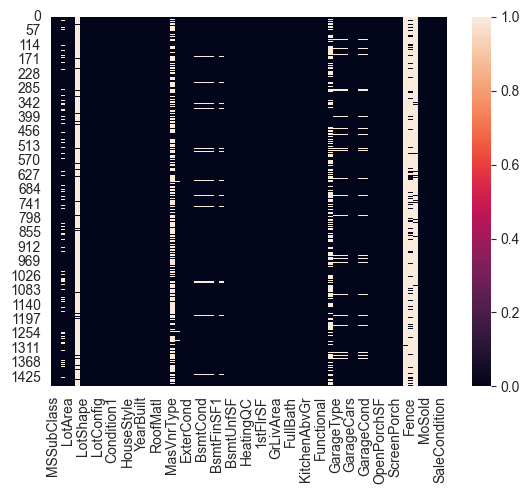

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

In [258]:
sns.heatmap(data.isna())
plt.show()
data.isna().sum()[data.isna().sum() != 0]/1460*100

In [259]:
data = data.drop(columns=['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'])
for col in ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']:
    data[col].fillna(data[col].median(), inplace=True)
for col in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
            'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [260]:
test = pd.read_csv("test.csv")
ids = test['Id']
test[["GrLivArea", "TotalBsmtSF"]] = np.log1p(test[["GrLivArea", "TotalBsmtSF"]])
test.loc[test["GarageArea"] != 0, "GarageArea"] = np.log(test.loc[test["GarageArea"] != 0, "GarageArea"])
test = test.drop(columns=['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature','Id'])
for col in ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']:
    test[col].fillna(data[col].median(), inplace=True)
for col in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
            'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
    test[col].fillna('missing', inplace=True)
test[test.select_dtypes(include = 'object').columns] = test.select_dtypes(include = 'object').fillna('0')
test[test.select_dtypes(exclude = 'object').columns] = test.select_dtypes(exclude = 'object').fillna(0)

In [267]:
from catboost import CatBoostRegressor

target = "SalePrice"

X = data.drop(columns=target)
y = data[target]

X_whole = pd.concat([X, test], axis=0)

cat_cols = X_whole.select_dtypes(include='object').columns
for col in cat_cols:
    X_whole = pd.concat([X_whole,pd.get_dummies(X_whole[col], prefix=col, drop_first=True)], axis = 1)
    X_whole = X_whole.drop(columns = col)

print(X_whole.columns)

X = X_whole.iloc[:len(data), :].copy()
test = X_whole.iloc[len(data):, :].copy()

model = CatBoostRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.7,
    reg_lambda=0.5,
    random_state=42
)
model.fit(X, y)
preds = np.expm1(model.predict(test))

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLI_True_True_True', 'SaleType_ConLw_True_True_True',
       'SaleType_New_True_True_True', 'SaleType_Oth_True_True_True',
       'SaleType_WD_True_True_True', 'SaleCondition_AdjLand_True_True_True',
       'SaleCondition_Alloca_True_True_True',
       'SaleCondition_Family_True_True_True',
       'SaleCondition_Normal_True_True_True',
       'SaleCondition_Partial_True_True_True'],
      dtype='object', length=237)
0:	learn: 0.3853903	total: 6.32ms	remaining: 12.6s
1:	learn: 0.3726626	total: 12.5ms	remaining: 12.5s
2:	learn: 0.3607761	total: 19.1ms	remaining: 12.7s
3:	learn: 0.3492494	total: 23.2ms	remaining: 11.6s
4:	learn: 0.3384970	total: 26.2ms	remaining: 10.4s
5:	learn: 0.3282530	total: 29.4ms	remaining: 9.77s
6:	learn: 0.3177344	total: 32.2ms	remaining: 9.18s
7:	learn: 0.3083938	total: 35.2ms	rema

In [268]:
df = pd.DataFrame({'Id':ids,'SalePrice':preds})
df.to_csv('my_data.csv', index = False)

print("List saved to my_data.csv")

List saved to my_data.csv
